# Configuración de la radio definida por Software

In [162]:
#---------------------------------------------------------------------------------
#Project     : Caracterizacion del ruido del canal inhalambrico
# Authors    : Brigido Tomas Andres, Lugones Oviedo Facundo Luis, Tosolini Agustin
# Affiliation: UNC
# E-mail     : 
#---------------------------------------------------------------------------------

En esta notebook nos centraremos principalmente en la descripción y configuración de los parámetros que controlan al AD9363. Para ello se hace uso de la interfaz [pyadi-iio](https://pypi.org/project/pyadi-iio/), un módulo diseñado en lenguaje Python, que permite interactuar con los dispositivos diseñados por Analog Device con un alto grado de abstracción. Para su instalación se debe ejecutar

In [163]:
#!pip install pyadi-iio

mientras que para su uso hay que importar la siguiente biblioteca

In [164]:
import adi

esto permitirá tener acceso a distintas clases de Python, entre las cuales se encuentran las asociadas al SDR y a los AD936x. Con estas clases se pueden generar objetos cuyas propiedades van a ser utilizadas para reconfigurar el hardware en cuestión. 

Otras instalaciones que van a servir para mas adelante son las siguientes:

In [165]:
#! pip install matplotlib
#! pip install scikit-dsp-comm
#! pip install scikit-commpy

En las siguientes lineas de código se crea el objeto "sdr" y se lo vincula con el dispositivo que se encuentra en la dirección proporcionada por la variable "Uri".

In [166]:
Uri = "ip:192.168.1.33"
sdr = adi.Pluto(Uri)

In [167]:
#------------------------------- Libraries ------------------------------- 
import numpy as np
import matplotlib.pyplot as plt

In [168]:
nSamples     = 2**20
samplingRate = 2.0e6
frec         = samplingRate/8

## Parámetros de configuración del SDR

In [169]:
#------------------------------- SDR Parameter Configuration -------------------------------
Uri              = Uri
Loopback         = 0             # 0=Disabled, 1=Digital loopback, 2=Retransmiter
SamplingRate     = samplingRate  # Sample rate RX and TX paths[Samples/Sec]

TxLOFreq         = 915e6         # Carrier frequency of TX path [Hz]
TxAtten          = -70           # Attenuation applied to TX path, valid range is -89 to 0 dB [dB]
TxRfBw           = 2.0e6         # Bandwidth of front-end analog filter of TX path [Hz]
RxBufferSize     = nSamples      # Depend on the length of the transmit signal. Maximum tx buffer size 2**24[samples]
tx_cyclic_buffer = False

RxLOFreq         = TxLOFreq      # Carrier frequency of RX path [Hz]
GainControlModes = "manual" # Receive path AGC Options: slow_attack, fast_attack, manual
RxHardwareGain   = 70            # Gain applied to RX path. Only applicable when gain_control_mode is set to 'manual'    
RxRfBw           = TxRfBw        # Bandwidth of front-end analog filter of RX path [Hz] 
RxBufferSize     = 2**20       # Rx Buffer size. Maximun value 2**28 [Samples]

In [170]:
sdr.loopback = Loopback

## Frecuencia de muestreo
El segundo parámetro de configuración a describir es el "sdr.sample_rate". Este parámetro define la frecuencia a la cual el AD9363 va a estar procesando las muestras digitales correspondientes a las componentes en fase y en cuadratura de la parte transmisora y receptora. Para el caso en que los datos digitales sean generados o entregados un Host remoto de forma continua, como por ejemplo una computadora, la máxima frecuencia de muestreo a configurar va a depender del límite de velocidad soportado por el tipo de conexión al Host remoto.

- **Rango de la frec. de muestreo: 521 KSPS a 61.44 MSPS**

In [171]:
sdr.sample_rate = samplingRate  # Sample rate RX and TX paths[Samples/Sec]

## Ancho de banda en RF
En la parte receptora, la señal que sale de los mezcladores de RF es filtrada para eliminar los efectos de alias y para reducir la interferencia y el ruido fuera de banda. Un amplificador de transimpedancia (TIA) y un filtro analógico se configuran y funcionan de forma conjunta para mantener el ancho de banda analógico deseado, cuyo rango va desde los 200 kHz hasta los 20 MHz. El TIA actúa como un filtro de un polo y el filtro analógico es un filtro Butterworth de tercer orden programable.
- **Rango del ancho de banda en RF del transmisor y del receptor: 200Khz a 20 Mhz**

In [172]:
sdr.tx_rf_bandwidth = int(TxRfBw)  # Bandwidth of front-end analog filter of TX path [Hz]
sdr.rx_rf_bandwidth = int(RxRfBw)  # Bandwidth of front-end analog filter of RX path [Hz] 

# Ganancia de Hardware

In [173]:
sdr.tx_hardwaregain_chan0   = TxAtten # Attenuation applied to TX path, valid range is -90 to 0 dB [dB]
sdr.rx_hardwaregain_chan0   = RxHardwareGain   # Gain applied to RX path. Only applicable when gain_control_mode is set to 'manual'
sdr.gain_control_mode_chan0 = GainControlModes # Receive path AGC Options: slow_attack, fast_attack, manual

## Frecuencia de portadora
El transceptor cuenta con un par de mezcladores en cuadratura en la parte transmisora/receptora, los cuales permiten procesar/obtener las componentes en fase y cuadratura y realizar su traslado en frecuencia. Desde el punto de vista del receptor, la arquitectura implementada para llevar la señal de RF a banda base es la llamada conversión directa (o Zero Forcing). En este tipo de arquitectura no se hace uso de etapas de frecuencia intermedia. El rango de operación de los mezcladores va desde los 325 Mhz hasta los 3.8 Ghz, pero se pueden hacer [modificaciones](https://wiki.analog.com/university/tools/pluto/users/customizing) en el software para ampliar este rango.

- **Rango de los osciladores de RF en el transmisor y en el receptor: 325 Mhz a 3.800 Mhz**


In [174]:
sdr.tx_lo = int(TxLOFreq)# Carrier frequency of TX path [Hz]
sdr.rx_lo = int(RxLOFreq) # Carrier frequency of RX path [Hz]

## Buffers

In [175]:
sdr.rx_buffer_size   = RxBufferSize
sdr.tx_cyclic_buffer = tx_cyclic_buffer
#sdr._ctrl.context.set_timeout(0) # <- disable timeout if you want to use large buffer size

## Transmitiendo y Recibiendo
Las lineas de código que permiten transmitir y recibir las señales por el SDR son:

In [176]:
#------------------------------- Receiver ------------------------------- 
rxSignal = sdr.rx()

In [177]:
# Se pasa a un vector de python para facilitar los calculos posteriores
x = list(rxSignal)
N = len(x)

if N < 2:
    raise ValueError("Se necesitan al menos 2 muestras para varianza insesgada.")

# Media muestral
acum = 0
for xi in x:
    acum += xi
media = acum / N

# Varianza: suma de cuadrados respecto de la media
acum2 = 0
for xi in x:
    d = xi - media
    acum2 += abs(d) ** 2

# Varianza tipo MLE (divide por N)
var_mle = acum2 / N

print("N =", N)
print("Media =", media)
print("Varianza =", var_mle)

N = 1048576
Media = (0.0030946731567382812-0.028104782104492188j)
Varianza = 243.98513670654236


In [178]:
import numpy as np

# Para señal compleja:
mu_c = np.mean(x)                               # media compleja
var_c_mle = np.mean(np.abs(x - mu_c)**2)        # varianza (MLE, divide por N)

# Por componentes I/Q (útil para ruido en banda base)
I = np.real(x)
Q = np.imag(x)

mu_I = np.mean(I)
mu_Q = np.mean(Q)

var_I_mle = np.var(I, ddof=0)   # divide por N
var_Q_mle = np.var(Q, ddof=0)

print(f"N = {N}")
print(f"Media compleja = {mu_c}")
print(f"Varianza compleja = {var_c_mle}")
print(f"Media Real = {mu_I}, Var(Real) MLE = {var_I_mle}")
print(f"Media Imaginaria = {mu_Q}, Var(Imaginaria) MLE = {var_Q_mle}")

N = 1048576
Media compleja = (0.0030946731567382812-0.028104782104492188j)
Varianza compleja = 243.98513670907687
Media Real = 0.0030946731567382812, Var(Real) MLE = 122.67064567354737
Media Imaginaria = -0.028104782104492188, Var(Imaginaria) MLE = 121.3144910355295


Gráfica temporal de la señal recibida

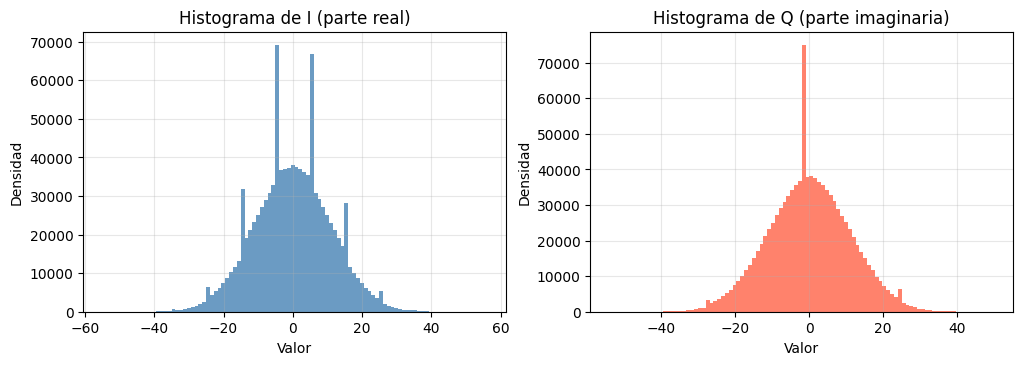

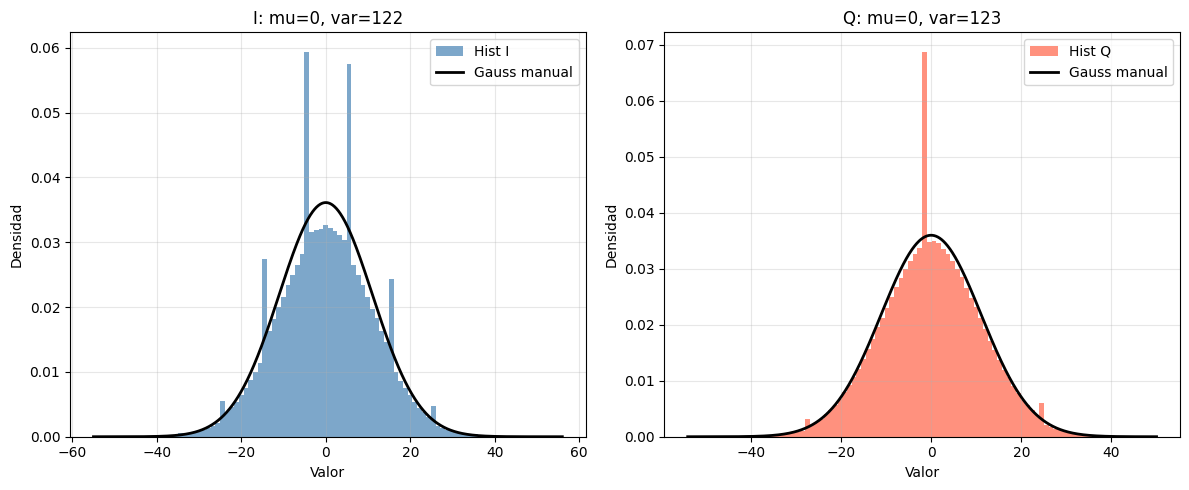

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

I = np.real(x)
Q = np.imag(x)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
# density = True normaliza el histograma a una función de densidad (área total = 1)
plt.hist(I, bins=100, density=True, alpha=0.8, color="steelblue")
plt.title("Histograma de I (parte real)")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.hist(Q, bins=100, density=True, alpha=0.8, color="tomato")
plt.title("Histograma de Q (parte imaginaria)")
plt.xlabel("Valor")
plt.ylabel("Densidad")
plt.grid(True, alpha=0.3)

# -------------------- Parametros ajustables a mano --------------------
# Cambialos y volve a ejecutar la celda
mu_I_user  = 0.0
var_I_user = 122

mu_Q_user  = 0.0
var_Q_user = 123
# ---------------------------------------------------------------------

if var_I_user <= 0 or var_Q_user <= 0:
    raise ValueError("La varianza debe ser > 0")

def gaussian_pdf(z, mu, var):
    return (1.0 / np.sqrt(2.0 * np.pi * var)) * np.exp(-((z - mu) ** 2) / (2.0 * var))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma I + gaussiana manual
ax[0].hist(I, bins=100, density=True, alpha=0.7, color="steelblue", label="Hist I")
zI = np.linspace(np.min(I), np.max(I), 1000)
ax[0].plot(zI, gaussian_pdf(zI, mu_I_user, var_I_user), "k", lw=2, label="Gauss manual")
ax[0].set_title(f"I: mu={mu_I_user:.3g}, var={var_I_user:.3g}")
ax[0].set_xlabel("Valor")
ax[0].set_ylabel("Densidad")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Histograma Q + gaussiana manual
ax[1].hist(Q, bins=100, density=True, alpha=0.7, color="tomato", label="Hist Q")
zQ = np.linspace(np.min(Q), np.max(Q), 1000)
ax[1].plot(zQ, gaussian_pdf(zQ, mu_Q_user, var_Q_user), "k", lw=2, label="Gauss manual")
ax[1].set_title(f"Q: mu={mu_Q_user:.3g}, var={var_Q_user:.3g}")
ax[1].set_xlabel("Valor")
ax[1].set_ylabel("Densidad")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

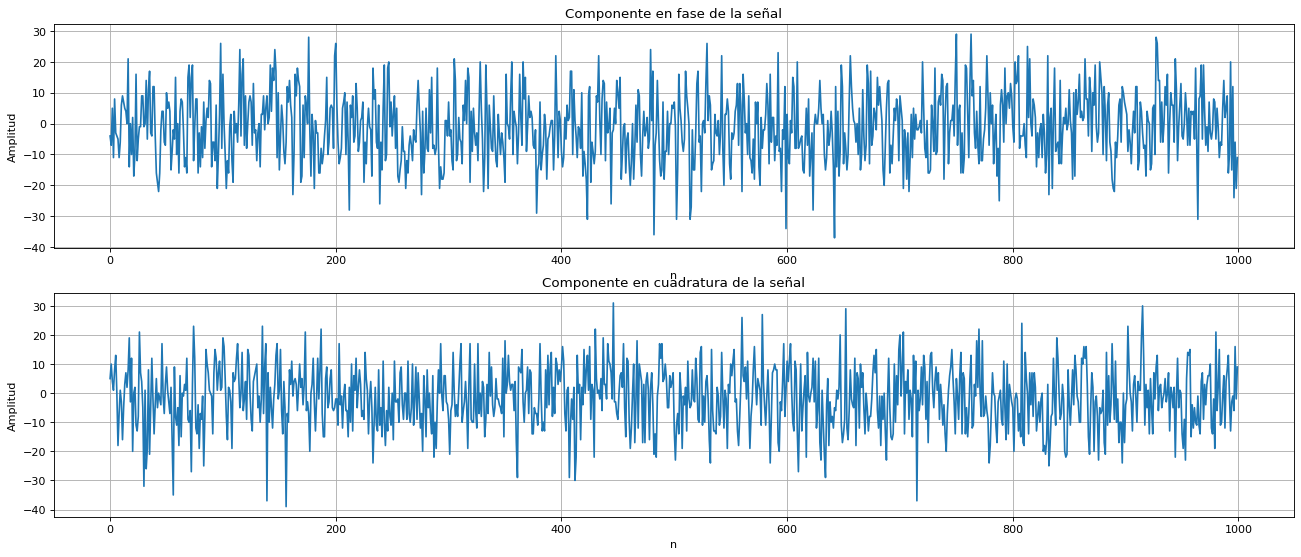

In [180]:
plotSignal(rxSignal[0:1000])

Gráfica de la densidad espectral de potencia de la señal recibida

/tmp/ipykernel_13002/2174936586.py:5: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(signal, len(signal), samplingRate, color='C1')


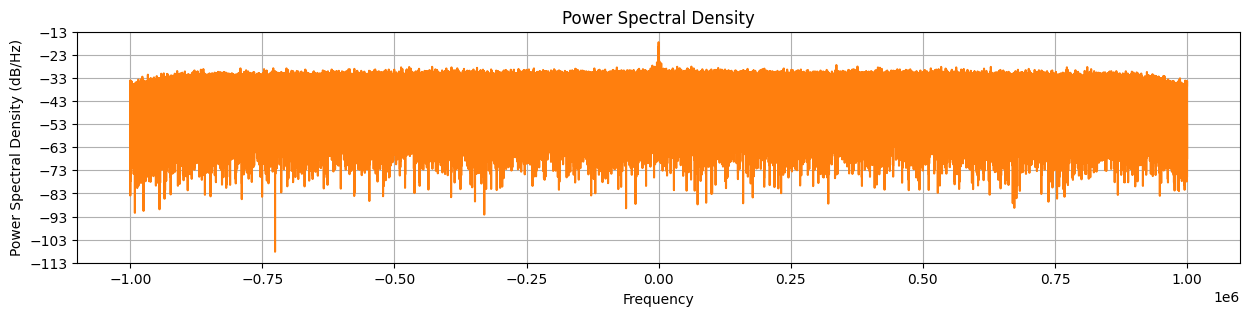

In [181]:
plotSpect(rxSignal,samplingRate)


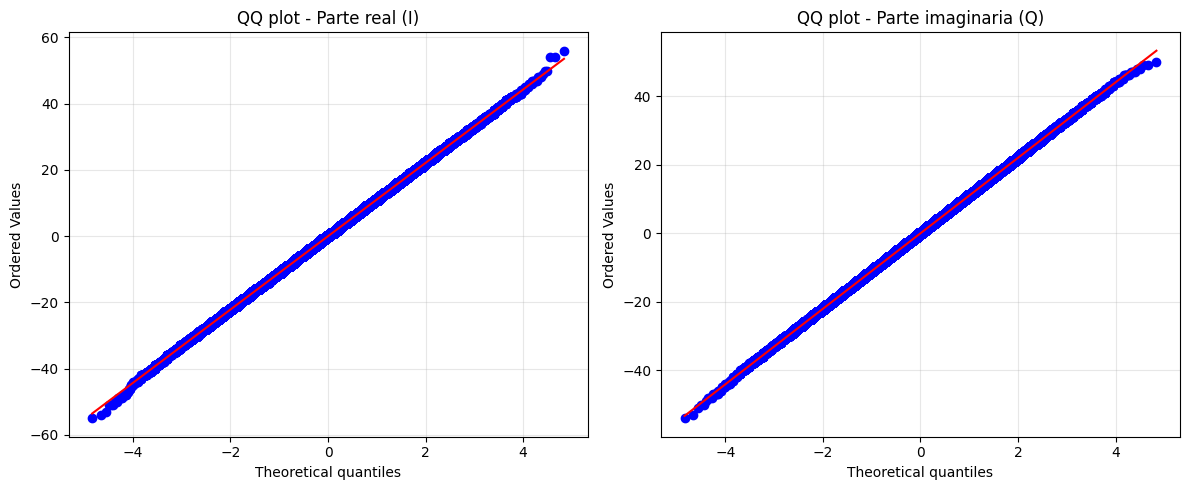

In [182]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Tomar canal 0 si rxSignal viene en lista/tupla
x = rxSignal[0] if isinstance(rxSignal, (list, tuple)) else rxSignal

I = np.real(x)
Q = np.imag(x)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# QQ plot para I
stats.probplot(I, dist="norm", plot=ax[0])
ax[0].set_title("QQ plot - Parte real (I)")
ax[0].grid(True, alpha=0.3)

# QQ plot para Q
stats.probplot(Q, dist="norm", plot=ax[1])
ax[1].set_title("QQ plot - Parte imaginaria (Q)")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [183]:
#num_symbols = 1000
#plt.figure(figsize=(3,3))
#plt.plot(np.real(rxSignal[0:num_symbols]),np.imag(rxSignal[0:num_symbols]),'b*')
#plt.grid()
#plt.show()

## Finalizando la experiencia
Dado que no es posible apagar la etapa transmisora del SDR, es recomendable antes de finalizar la experiencia, dejar configurado el transmisor con la máxima atenuación posible, asegurarse que las frecuencias de transmisión y recepción no coinciden y cargar al Buffer transmisor con ceros. Esto permitirá minimizar cualquier posible interferencia por parte del SDR.

In [184]:
# Since it is not possible to turn off Tx, it is configured to transmit at low power and on a different frequency than Rx.
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = -89 
sdr.tx_lo                 = int(2400e6)
sdr.rx_lo                 = int(950e6)
sdr.tx(np.zeros(2048))

In [185]:
# Destroy radio object
del(sdr)

# Conclusion

Buen trabajo